# **Supermarket Sales Data Analysis Report (2014–2015)**

**Hello, my name is Abraham, and I use `data analysis to tell clearer stories about how businesses operate and grow.`**

**In this project, I will analyze a two-year supermarket transaction dataset using Python and Jupyter Notebook. The analysis focuses on uncovering insights related to revenue, product performance, customer purchasing patterns and regional sales trends.**

**This project is structured like a real-world business case scenario where a supermarket company provides transactional data for performance evaluation and decision-making.**


## **Dataset Source and Description**

**The dataset used in this project is a supermarket transaction dataset gotten from [Mendeley Data](https://data.mendeley.com/datasets/tjc4jx3srm/1). It contains customer demographics, product information, regional sales details and revenue-related metrics from 2014 to 2015.**

**The dataset includes transactional records such as:**

**1. Purchase dates**

**2. Customer information**

**3. Product categories**

**4. Product departments**

**5. Geographic locations**

**6. Units sold**

**7. Revenue generated**

**8. Income groups**

**9. Family demographics**


**This dataset is used strictly for educational, analytical and portfolio purposes.**


> **kingori, nimrod (2021), “Supermarket Data”, Mendeley Data, V1, doi: 10.17632/tjc4jx3srm.1**


## **Business Problem**

**The supermarket company wants to better understand:**

- **Overall business performance**

- **Customer purchasing behavior**

- **Product performance**

- **Regional sales trends**

- **Revenue growth between 2014 and 2015**


**The goal is to turn raw transaction data into actionable business insights that can support smarter business decisions.**


## **Key Business Questions**

**Some of the questions this analysis will answer include:**

**1. Which year generated the highest revenue?**

**2. Which products perform best?**

**3. Which customer groups spend the most?**

**4. Which locations generate the highest sales?**

**5. What factors influence revenue growth?**

**6. Which areas of the business require improvement?**





In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
raw_data = pd.read_excel(r'C:\Users\DELL\Desktop\New folder\Supermarket sales data across the US.xlsx')
raw_data

,Transaction,Purchase Date,Customer ID,Gender,Marital Status,Homeowner,Children,Annual Income,City,State or Province,Country,Product Family,Product Department,Product Category,Units Sold,Revenue
0,1,2014-12-18 00:00:00,7223,F,S,Y,2,$30K - $50K,Los Angeles,CA,USA,Food,Snack Foods,Snack Foods,5,27.38
1,2,2014-12-20 00:00:00,7841,M,M,Y,5,$70K - $90K,Los Angeles,CA,USA,Food,Produce,Vegetables,5,14.90
2,3,2014-12-21 00:00:00,8374,F,M,N,2,$50K - $70K,Bremerton,WA,USA,Food,Snack Foods,Snack Foods,3,5.52
3,4,2014-12-21 00:00:00,9619,M,M,Y,3,$30K - $50K,Portland,OR,USA,Food,Snacks,Candy,4,4.44
4,5,2014-12-22 00:00:00,1900,F,S,Y,3,$130K - $150K,Beverly Hills,CA,USA,Drink,Beverages,Carbonated Beverages,4,14.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14054,14055,2016-12-29 00:00:00,9102,F,M,Y,2,$10K - $30K,Bremerton,WA,USA,Food,Baking Goods,Baking Goods,3,9.64
14055,14056,2016-12-29 00:00:00,4822,F,M,Y,3,$10K - $30K,Walla Walla,WA,USA,Food,Frozen Foods,Vegetables,3,7.45
14056,14057,2016-12-31 00:00:00,250,M,S,Y,1,$30K - $50K,Portland,OR,USA,Drink,Beverages,Pure Juice Beverages,4,3.24
14057,14058,2016-12-31 00:00:00,6153,F,S,N,4,$50K - $70K,Spokane,WA,USA,Drink,Dairy,Dairy,2,4.00


In [3]:
raw_data.shape

(14059, 16)

In [4]:
raw_data.columns

Index(['Transaction', 'Purchase Date', 'Customer ID', 'Gender',
       'Marital Status', 'Homeowner', 'Children', 'Annual Income', 'City',
       'State or Province', 'Country', 'Product Family', 'Product Department',
       'Product Category', 'Units Sold', 'Revenue'],
      dtype='object')

In [5]:
raw_data.duplicated().sum()

np.int64(0)

In [6]:
raw_data.isnull().sum()

Transaction           0
Purchase Date         0
Customer ID           0
Gender                0
Marital Status        0
Homeowner             0
Children              0
Annual Income         0
City                  0
State or Province     0
Country               0
Product Family        0
Product Department    0
Product Category      0
Units Sold            0
Revenue               0
dtype: int64

In [7]:
raw_data.nunique()

Transaction           14059
Purchase Date           742
Customer ID            5404
Gender                    2
Marital Status            2
Homeowner                 2
Children                  6
Annual Income             8
City                     23
State or Province        10
Country                   3
Product Family            3
Product Department       22
Product Category         45
Units Sold                8
Revenue                2846
dtype: int64

In [8]:
b=list(raw_data['Gender'].unique())
c=list(raw_data['Marital Status'].unique())
d=list(raw_data['Homeowner'].unique())
e=list(raw_data['Children'].unique())
f=list(raw_data['Annual Income'].unique())
g=list(raw_data['City'].unique())
h=list(raw_data['State or Province'].unique())
i=list(raw_data['Country'].unique())
j=list(raw_data['Product Family'].unique())
k=list(raw_data['Product Department'].unique())
l=list(raw_data['Product Category'].unique())
m=list(raw_data['Units Sold'].unique())

print("""

Gender: {}

Marital Status: {}

Homeowner: {}

Children: {}

Annual Income: {}

City: {}

State: {}

Country: {}

Product Family: {}

Product Department: {}

Product Category: {}

Units Sold: {}

""". format(b,c,d,e,f,g,h,i,j,k,l,m))



Gender: ['F', 'M']

Marital Status: ['S', 'M']

Homeowner: ['Y', 'N']

Children: [np.int64(2), np.int64(5), np.int64(3), np.int64(1), np.int64(0), np.int64(4)]

Annual Income: ['$30K - $50K', '$70K - $90K', '$50K - $70K', '$130K - $150K', '$10K - $30K', '$150K +', '$90K - $110K', '$110K - $130K']

City: ['Los Angeles', 'Bremerton', 'Portland', 'Beverly Hills', 'Salem', 'Yakima', 'Bellingham', 'San Diego', 'Tacoma', 'San Francisco', 'Seattle', 'Walla Walla', 'Spokane', 'Orizaba', 'Merida', 'Vancouver', 'Camacho', 'Hidalgo', 'Victoria', 'San Andres', 'Acapulco', 'Mexico City', 'Guadalajara']

State: ['CA', 'WA', 'OR', 'Veracruz', 'Yucatan', 'BC', 'Zacatecas', 'DF', 'Guerrero', 'Jalisco']

Country: ['USA', 'Mexico', 'Canada']

Product Family: ['Food', 'Drink', 'Non-Consumable']

Product Department: ['Snack Foods', 'Produce', 'Snacks', 'Beverages', 'Deli', 'Frozen Foods', 'Canned Foods', 'Household', 'Health and Hygiene', 'Baking Goods', 'Dairy', 'Periodicals', 'Alcoholic Beverages', 'Ch

In [9]:
dtype_change = {'Gender':'category', 'Marital Status':'category', 'Homeowner':'category', 'Annual Income':'category', 
               'City':'string', 'State or Province':'category', 'Country':'category', 'Product Family':'category', 'Product Department':'category',
                'Product Category':'string'}

raw_data['Purchase Date'] = pd.to_datetime(raw_data['Purchase Date'], errors='coerce').dt.date
raw_data = raw_data.astype(dtype_change)
raw_data.dtypes

Transaction                    int64
Purchase Date                 object
Customer ID                    int64
Gender                      category
Marital Status              category
Homeowner                   category
Children                       int64
Annual Income               category
City                  string[python]
State or Province           category
Country                     category
Product Family              category
Product Department          category
Product Category      string[python]
Units Sold                     int64
Revenue                      float64
dtype: object

In [10]:
raw_data.isnull().sum()

Transaction            0
Purchase Date         12
Customer ID            0
Gender                 0
Marital Status         0
Homeowner              0
Children               0
Annual Income          0
City                   0
State or Province      0
Country                0
Product Family         0
Product Department     0
Product Category       0
Units Sold             0
Revenue                0
dtype: int64

In [11]:
raw_data.dropna(inplace=True)
raw_data['Purchase Date'] = pd.to_datetime(raw_data['Purchase Date'])
raw_data.isnull().sum()

Transaction           0
Purchase Date         0
Customer ID           0
Gender                0
Marital Status        0
Homeowner             0
Children              0
Annual Income         0
City                  0
State or Province     0
Country               0
Product Family        0
Product Department    0
Product Category      0
Units Sold            0
Revenue               0
dtype: int64

In [12]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14047 entries, 0 to 14058
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction         14047 non-null  int64         
 1   Purchase Date       14047 non-null  datetime64[ns]
 2   Customer ID         14047 non-null  int64         
 3   Gender              14047 non-null  category      
 4   Marital Status      14047 non-null  category      
 5   Homeowner           14047 non-null  category      
 6   Children            14047 non-null  int64         
 7   Annual Income       14047 non-null  category      
 8   City                14047 non-null  string        
 9   State or Province   14047 non-null  category      
 10  Country             14047 non-null  category      
 11  Product Family      14047 non-null  category      
 12  Product Department  14047 non-null  category      
 13  Product Category    14047 non-null  string        


In [13]:
raw_data.describe()

,Transaction,Purchase Date,Customer ID,Children,Units Sold,Revenue
count,14047.000000,14047,14047.000000,14047.000000,14047.000000,14047.000000
mean,7035.460953,2016-02-26 15:27:19.951591168,5117.437460,2.530718,4.080444,13.003106
min,1.000000,2014-12-18 00:00:00,3.000000,0.000000,1.000000,0.530000
25%,3524.500000,2015-10-09 12:00:00,2549.000000,1.000000,3.000000,6.840000
50%,7036.000000,2016-03-29 00:00:00,5060.000000,3.000000,4.000000,11.250000
75%,10547.500000,2016-08-05 00:00:00,7633.000000,4.000000,5.000000,17.360000
max,14059.000000,2016-12-31 00:00:00,10280.000000,5.000000,8.000000,56.700000
std,4056.056363,NaN,2920.527475,1.492076,1.174419,8.214398


# **Exploratory Analysis and Visualization**





In [14]:
raw_data['Year'] = raw_data['Purchase Date'].dt.year
raw_data['Month'] = raw_data['Purchase Date'].dt.month_name()
sns.set_style('darkgrid')

In [15]:
pd.set_option('display.max_rows', 10)

# **1. Evaluate Overall Business Performance**

## **1a. Did overall revenue improve from 2015 to 2016?**

In [16]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
data = raw_data[raw_data['Year'] != 2014].copy()
data['Month'] = pd.Categorical(data['Month'], categories=month_order, ordered=True)
data =data.sort_values('Month').reset_index(drop=True)

data.sample(4)

,Transaction,Purchase Date,Customer ID,Gender,Marital Status,Homeowner,Children,Annual Income,City,State or Province,Country,Product Family,Product Department,Product Category,Units Sold,Revenue,Year,Month
5622,8010,2016-05-04,838,F,S,N,4,$50K - $70K,Camacho,Zacatecas,Mexico,Food,Snacks,Candy,5,6.27,2016,May
1352,5749,2016-02-09,10249,F,S,N,4,$30K - $50K,Los Angeles,CA,USA,Food,Produce,Vegetables,6,21.24,2016,February
9689,11432,2016-09-08,8649,M,M,Y,4,$50K - $70K,Acapulco,Guerrero,Mexico,Non-Consumable,Health and Hygiene,Bathroom Products,3,12.23,2016,September
7783,9646,2016-07-03,4029,M,M,N,3,$10K - $30K,Tacoma,WA,USA,Food,Snack Foods,Snack Foods,4,13.78,2016,July


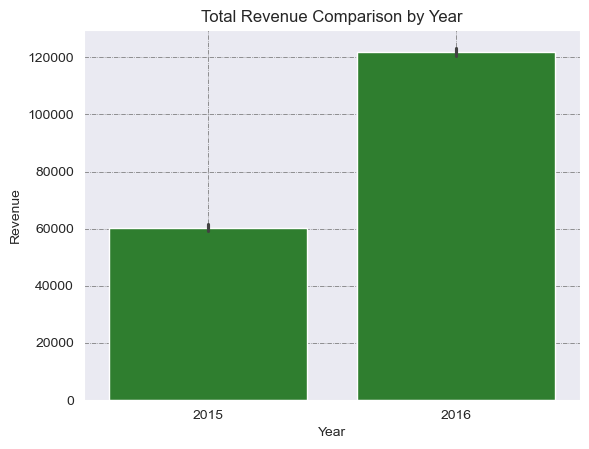

In [17]:
sns.barplot(data=data, x='Year', y='Revenue', estimator='sum', color='forestgreen')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Total Revenue Comparison by Year');

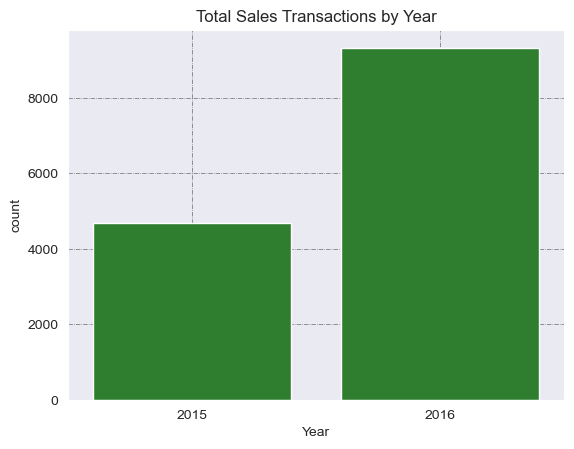

In [18]:
sns.countplot(data=data, x='Year', color='forestgreen')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Total Sales Transactions by Year');

In [53]:
h = data.groupby('Year', as_index=False).size()
h

,Year,size
0,2015,4680
1,2016,9332


## **1b. What monthly or seasonal sales trends can be identified?**

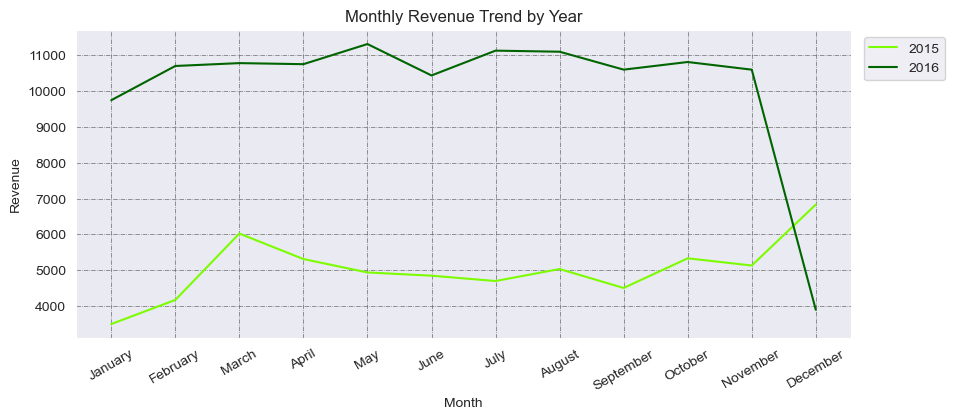

In [19]:
plt.figure(figsize=(10,4))
sns.lineplot(data=data, x='Month', y='Revenue', hue='Year', palette= ['lawngreen', 'darkgreen'], estimator='sum', errorbar=None)
plt.legend(bbox_to_anchor=(1.13,1))
plt.xticks(rotation=30)
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Monthly Revenue Trend by Year');

In [20]:
data['Purchase Period'] = data['Purchase Date'].dt.to_period('M')
period_revenue = data.groupby('Purchase Period')[['Revenue']].sum()
period_revenue.index = period_revenue.index.astype('string')
period_revenue.index.dtype
period_revenue

,Revenue
Purchase Period,
2015-01,3500.36
2015-02,4172.69
2015-03,6026.58
2015-04,5314.83
2015-05,4940.63
...,...
2016-08,11102.47
2016-09,10602.19
2016-10,10815.38


## **1c. Was business growth consistent throughout the period?**

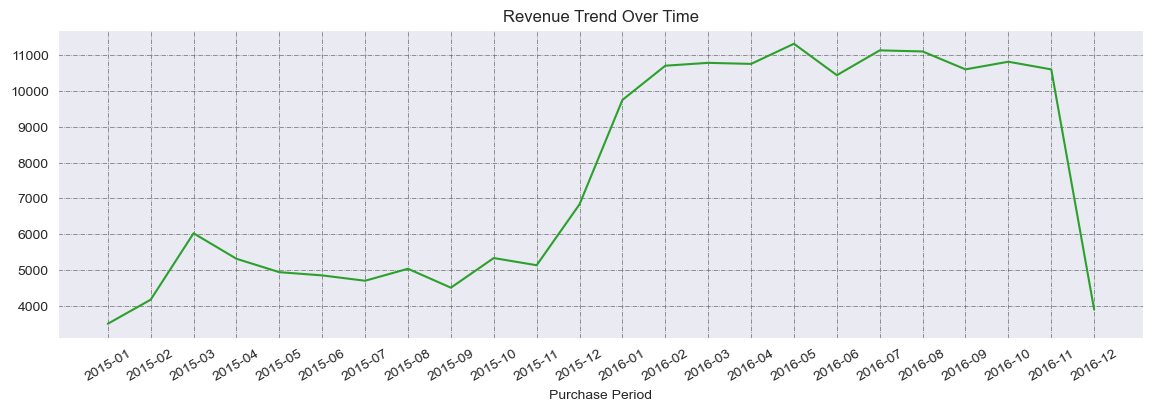

In [21]:
plt.figure(figsize=(14,4))
sns.lineplot(data=period_revenue, x=period_revenue.index, y=period_revenue.values.flatten(), color='tab:green')
plt.xticks(rotation=30)
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Revenue Trend Over Time');

# **2. Identify Top Performing Products & Departments**

## **2a. Which product categories generate the highest revenue?**

In [22]:
productcategory_revenue = data.groupby('Product Category', as_index=False, observed=False)[['Revenue']].sum().sort_values('Revenue', ascending=False).reset_index(drop=True)
productcategory_revenue

,Product Category,Revenue
0,Vegetables,23593.70
1,Snack Foods,21829.67
2,Dairy,12281.68
3,Meat,10154.27
4,Fruit,10091.83
...,...,...
40,Canned Shrimp,639.54
41,Candles,452.18
42,Miscellaneous,449.01
43,Canned Sardines,441.73


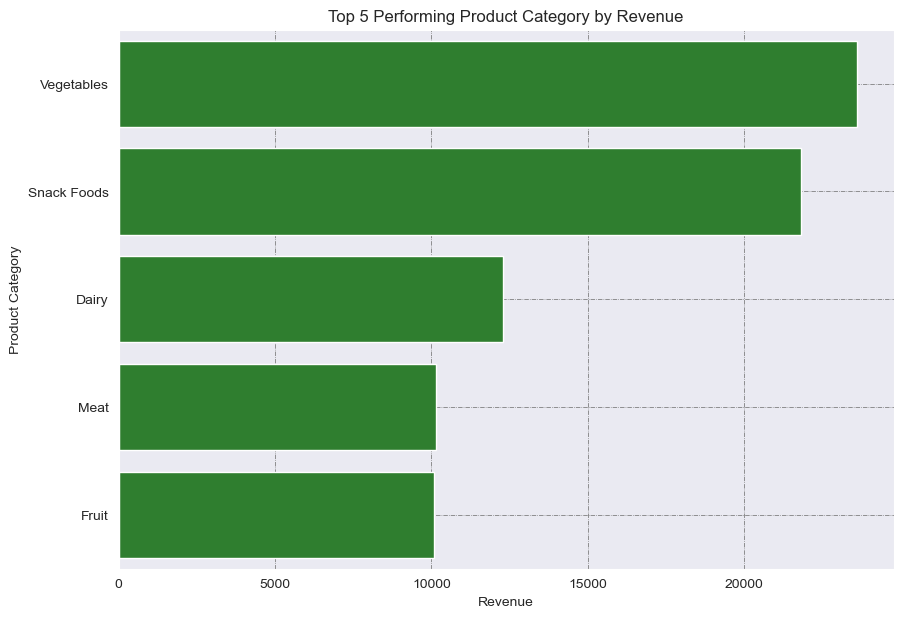

In [23]:
plt.figure(figsize=(10,7))
sns.barplot(data=productcategory_revenue.head(5), y='Product Category', x='Revenue', color='forestgreen', edgecolor='white')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Top 5 Performing Product Category by Revenue');

## **2b. Which product categories generate the least revenue?**

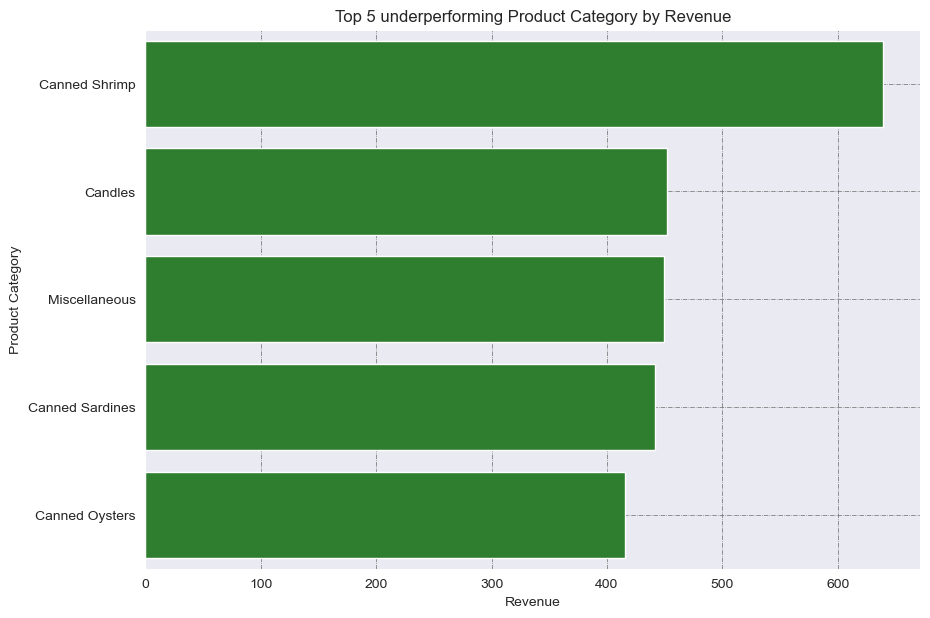

In [24]:
plt.figure(figsize=(10,7))
sns.barplot(data=productcategory_revenue.tail(5), y='Product Category', x='Revenue', color='forestgreen', edgecolor='white')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Top 5 underperforming Product Category by Revenue');

## **2c. Which departments sell the most units?**

In [25]:
productdepartment_unit = data.groupby('Product Department', as_index=False, observed=False).size().sort_values('size', ascending=False).reset_index(drop=True)
productdepartment_unit

,Product Department,size
0,Produce,1987
1,Snack Foods,1595
2,Household,1414
3,Frozen Foods,1378
4,Baking Goods,1070
...,...,...
17,Canned Products,109
18,Seafood,101
19,Meat,89
20,Checkout,81


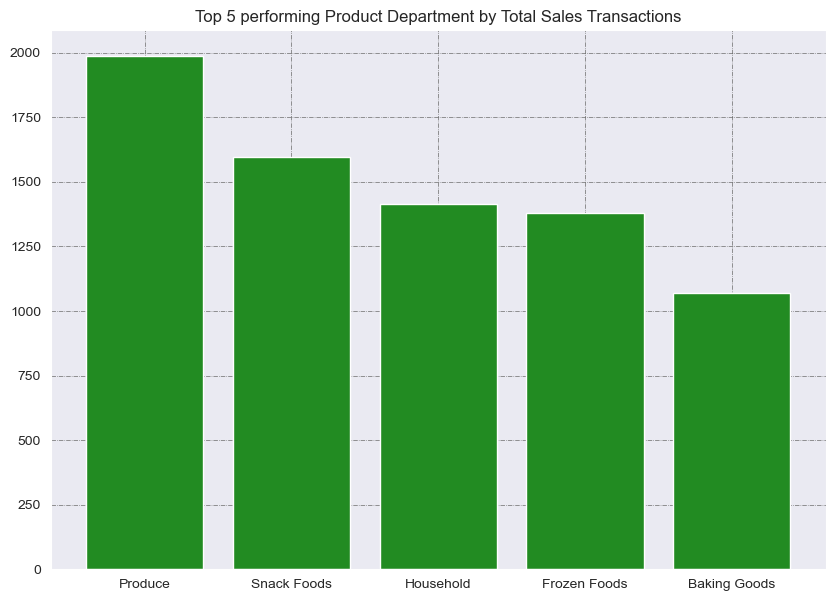

In [26]:
plt.figure(figsize=(10,7))
plt.bar(data=productdepartment_unit.head(5), x='Product Department', height='size', color='forestgreen', edgecolor='white')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Top 5 performing Product Department by Total Sales Transactions');

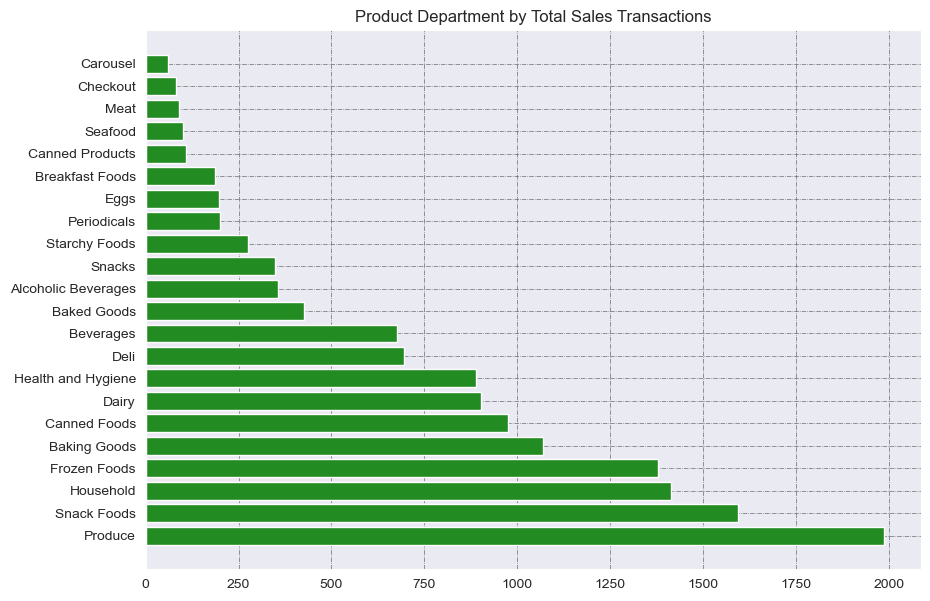

In [27]:
plt.figure(figsize=(10,7))
plt.barh(data=productdepartment_unit, y='Product Department', width='size', color='forestgreen', edgecolor='white')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Product Department by Total Sales Transactions');

# **3. Understand Customer Purchasing Behavior**

## **3a. Which customer groups contribute the most revenue?**

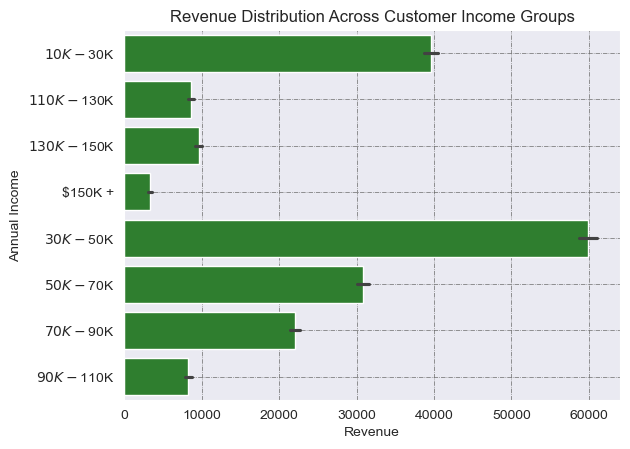

In [28]:
sns.barplot(data=data, y='Annual Income', x='Revenue', estimator='sum', color='forestgreen', edgecolor='white')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Revenue Distribution Across Customer Income Groups');

## **3b. Does annual income affect purchasing behavior?**

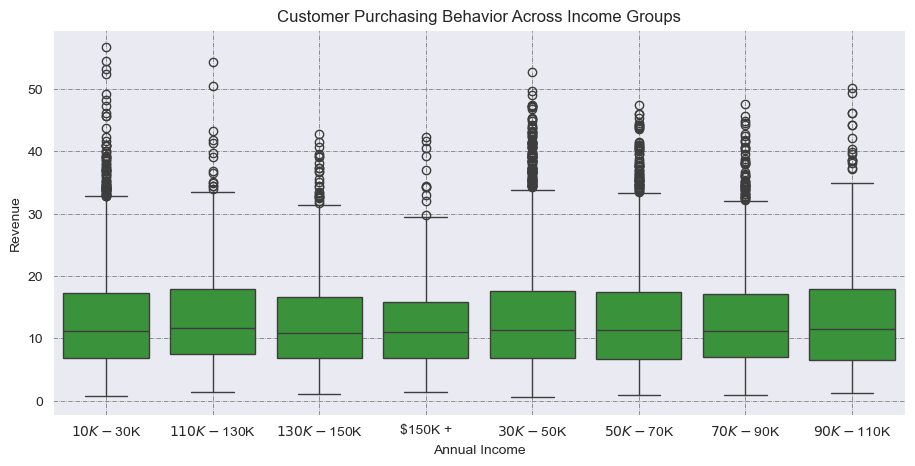

In [29]:
plt.figure(figsize=(11,5))
sns.boxplot(data=data, x='Annual Income', y='Revenue', color='tab:green')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Customer Purchasing Behavior Across Income Groups');

## **3c. How do factors like marital status, gender, and homeownership impact sales?**

In [30]:
a = data.groupby('Marital Status', as_index=False)[['Revenue']].sum()
a

C:\Users\DELL\AppData\Local\Temp\ipykernel_12260\1150403454.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a = data.groupby('Marital Status', as_index=False)[['Revenue']].sum()


,Marital Status,Revenue
0,M,88923.44
1,S,93332.83


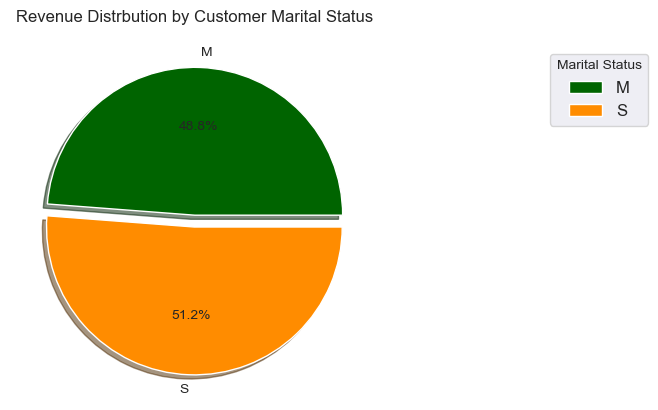

In [31]:
plt.pie(x=a['Revenue'].unique(), labels=a['Marital Status'].unique(), shadow=True,  explode=[0,0.08],autopct ='%.1f%%', colors=['darkgreen','darkorange'])
plt.legend(title='Marital Status', loc = 4,fontsize  = 12, bbox_to_anchor =(1.75, 0.72), ncol = 1)
plt.title('Revenue Distrbution by Customer Marital Status');

In [32]:
b = data.groupby('Gender', as_index=False)[['Revenue']].sum()
b

C:\Users\DELL\AppData\Local\Temp\ipykernel_12260\3788453803.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  b = data.groupby('Gender', as_index=False)[['Revenue']].sum()


,Gender,Revenue
0,F,93220.53
1,M,89035.74


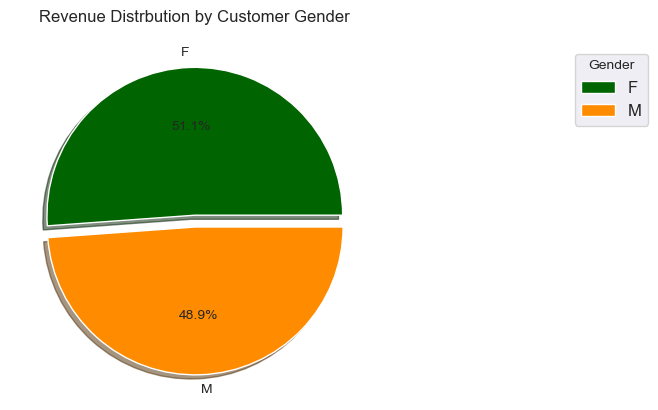

In [33]:
plt.pie(x=b['Revenue'].unique(), labels=b['Gender'].unique(), shadow=True,  explode=[0,0.08],autopct ='%.1f%%', colors=['darkgreen','darkorange'])
plt.legend(title='Gender', loc = 4,fontsize  = 12, bbox_to_anchor =(1.75, 0.72), ncol = 1)
plt.title('Revenue Distrbution by Customer Gender');

In [34]:
c = data.groupby('Homeowner', as_index=False)[['Revenue']].sum()
c

C:\Users\DELL\AppData\Local\Temp\ipykernel_12260\3872587264.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  c = data.groupby('Homeowner', as_index=False)[['Revenue']].sum()


,Homeowner,Revenue
0,N,72708.50
1,Y,109547.77


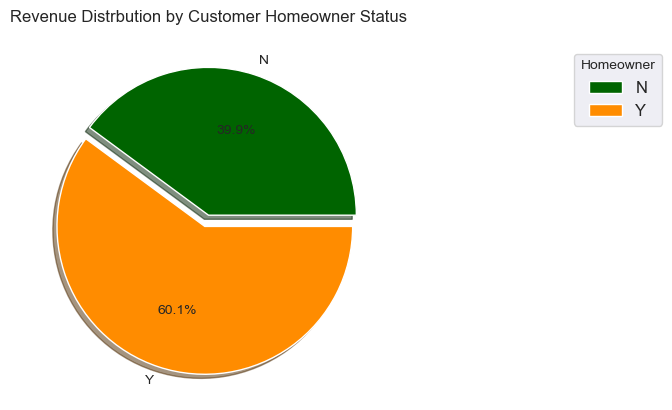

In [35]:
plt.pie(x=c['Revenue'].unique(), labels=c['Homeowner'].unique(), shadow=True,  explode=[0,0.08],autopct ='%.1f%%', colors=['darkgreen','darkorange'])
plt.legend(title='Homeowner', loc = 4,fontsize  = 12, bbox_to_anchor =(1.75, 0.72), ncol = 1)
plt.title('Revenue Distrbution by Customer Homeowner Status');

# **4. Analyze Regional Sales Performance**

## **4a. Which cities and states generate the highest revenue?**

In [36]:
city_revenue = data.groupby(['City'], as_index=False)[['Revenue']].sum().sort_values('Revenue', ascending=False).reset_index(drop=True)
city_revenue

,City,Revenue
0,Salem,18161.99
1,Tacoma,16755.23
2,Los Angeles,12232.20
3,Seattle,12152.39
4,Portland,11843.82
...,...,...
18,Victoria,2402.03
19,Walla Walla,1164.60
20,Bellingham,971.04
21,San Francisco,739.81


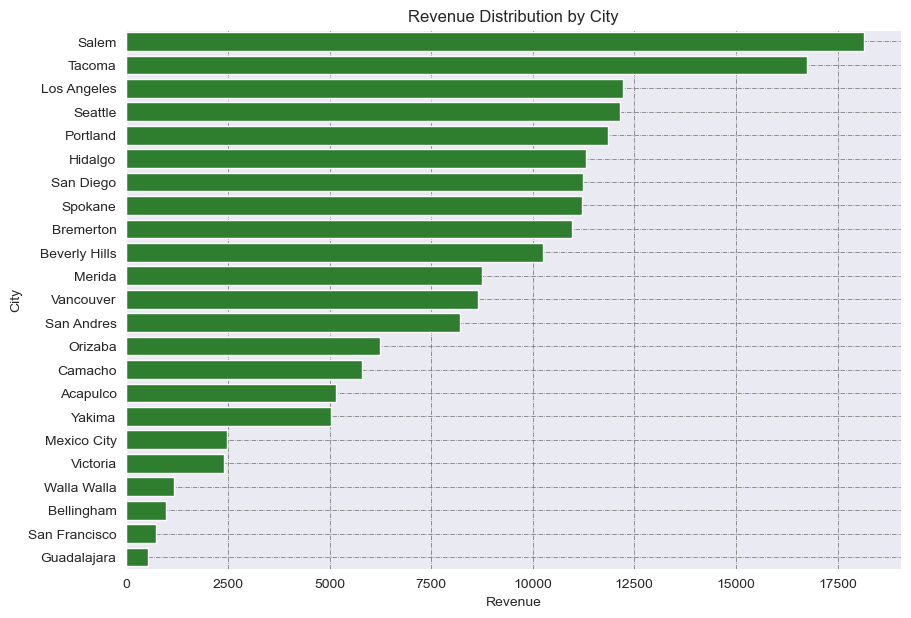

In [37]:
plt.figure(figsize=(10,7))
sns.barplot(data=city_revenue, y='City', x='Revenue', color='forestgreen', edgecolor='white')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Revenue Distribution by City');

## **4b. Which regions are underperforming?**

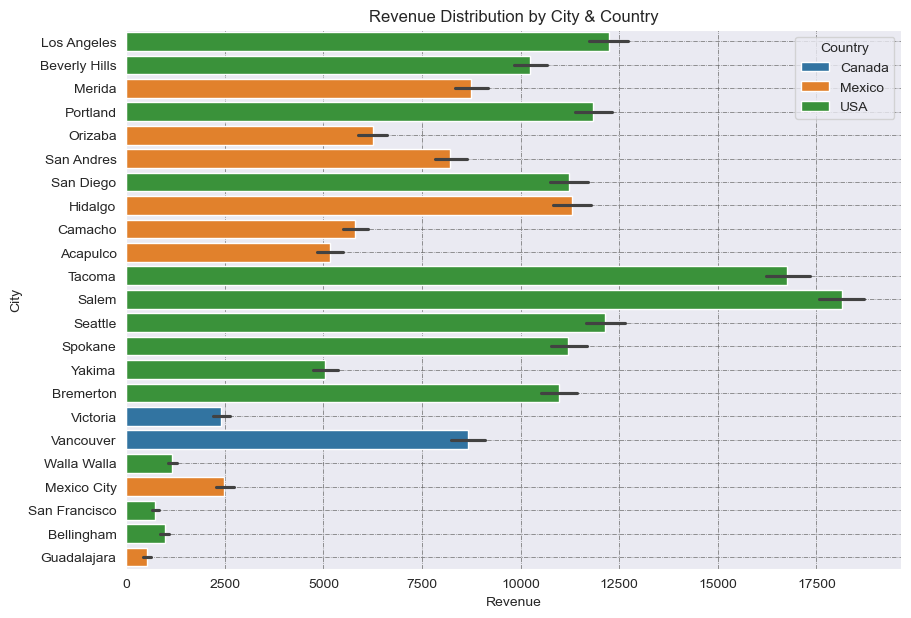

In [38]:
plt.figure(figsize=(10,7))
sns.barplot(data=data, y='City', x='Revenue', hue='Country', estimator='sum')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Revenue Distribution by City & Country');

## **4c. Which region showed the most growth?**

In [39]:
data=data.sort_values('Purchase Period').reset_index(drop=True)
data['Purchase Period'] = data['Purchase Period'].astype('string')
data['Purchase Period'].dtype

string[python]

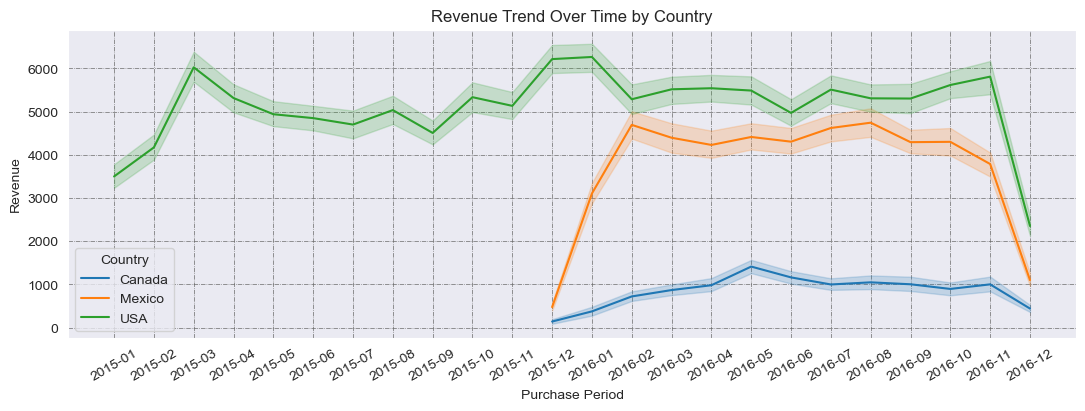

In [40]:
plt.figure(figsize=(13,4))
sns.lineplot(data=data, x='Purchase Period', y='Revenue', hue='Country',  estimator='sum')
plt.xticks(rotation=30)
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Revenue Trend Over Time by Country');

# **Business Questions**

## **A. Which Year Generated the highest revenue?**

In [41]:
c = data.groupby('Year', as_index=False)['Revenue'].sum()
c

,Year,Revenue
0,2015,60354.92
1,2016,121901.35


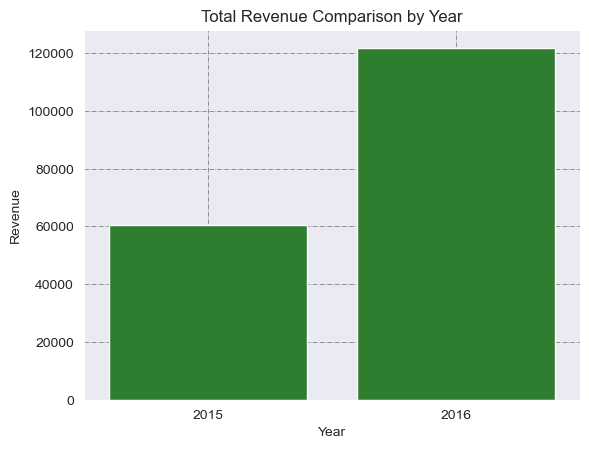

In [42]:
sns.barplot(data=c, x='Year', y='Revenue', estimator='sum', color='forestgreen')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Total Revenue Comparison by Year');

## **B. Which product categories perform best?**

In [43]:
d = data.groupby('Product Category', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False).reset_index(drop=True)
d

,Product Category,Revenue
0,Vegetables,23593.70
1,Snack Foods,21829.67
2,Dairy,12281.68
3,Meat,10154.27
4,Fruit,10091.83
...,...,...
40,Canned Shrimp,639.54
41,Candles,452.18
42,Miscellaneous,449.01
43,Canned Sardines,441.73


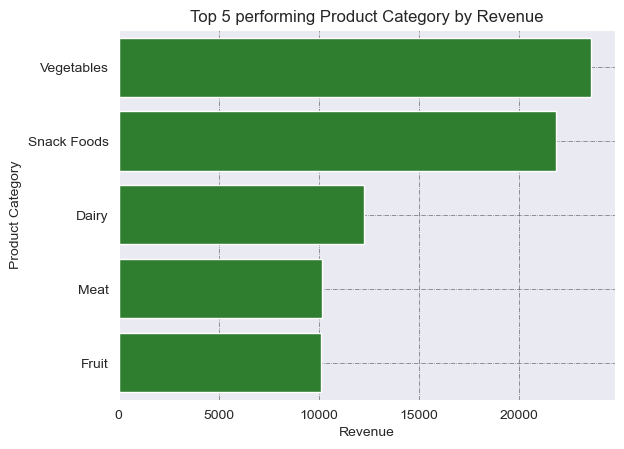

In [44]:
sns.barplot(data=d.head(5), y='Product Category', x='Revenue', estimator='sum', color='forestgreen')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Top 5 performing Product Category by Revenue');

## **C. Which customer segments spend the most?**

In [45]:
e = data.groupby('Annual Income', as_index=False)['Revenue'].agg(['mean', 'median']).round(1)
e = e.sort_values('mean', ascending=False).reset_index(drop=True)
e

C:\Users\DELL\AppData\Local\Temp\ipykernel_12260\350677788.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  e = data.groupby('Annual Income', as_index=False)['Revenue'].agg(['mean', 'median']).round(1)


,Annual Income,mean,median
0,$90K - $110K,13.5,11.5
1,$110K - $130K,13.4,11.7
2,$30K - $50K,13.1,11.3
3,$50K - $70K,13.0,11.4
4,$70K - $90K,13.0,11.2
5,$10K - $30K,12.9,11.1
6,$130K - $150K,12.7,10.8
7,$150K +,12.4,11.0


## **D. Which cities or states generate the highest sales?**

In [46]:
f = data.groupby('State or Province', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False).reset_index(drop=True)
f

C:\Users\DELL\AppData\Local\Temp\ipykernel_12260\3890388858.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  f = data.groupby('State or Province', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False).reset_index(drop=True)


,State or Province,Revenue
0,WA,58256.64
1,CA,34451.91
2,OR,30005.81
3,Zacatecas,17110.22
4,BC,11067.03
5,DF,10694.36
6,Yucatan,8740.45
7,Veracruz,6245.22
8,Guerrero,5161.31
9,Jalisco,523.32


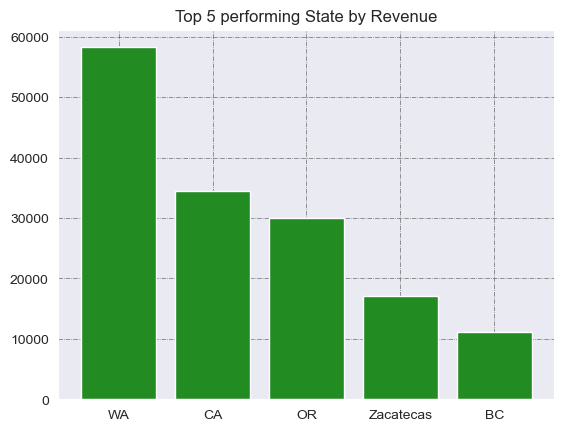

In [47]:
plt.bar(data=f.head(5), x='State or Province', height='Revenue', color='forestgreen')
plt.grid(color='dimgray',  linestyle='-.', linewidth='0.5')
plt.title('Top 5 performing State by Revenue');

## **E. What products contribute most to revenue?**

In [48]:
g = data.groupby('Product Family', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False).reset_index(drop=True)
g

C:\Users\DELL\AppData\Local\Temp\ipykernel_12260\1390151092.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = data.groupby('Product Family', as_index=False)['Revenue'].sum().sort_values('Revenue', ascending=False).reset_index(drop=True)


,Product Family,Revenue
0,Food,132409.90
1,Non-Consumable,34045.80
2,Drink,15800.57


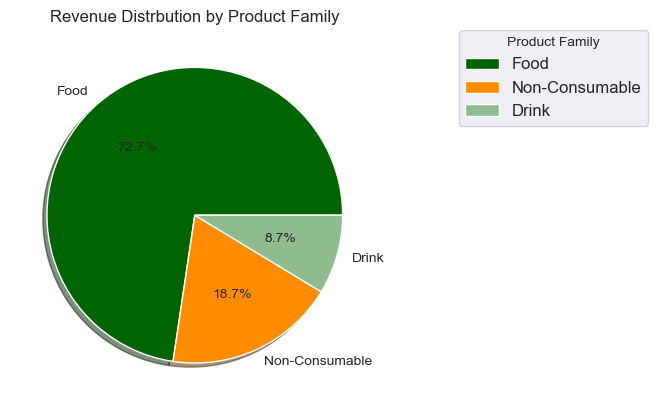

In [49]:
plt.pie(x=g['Revenue'].unique(), labels=g['Product Family'].unique(), shadow=True,autopct ='%.1f%%', colors=['darkgreen','darkorange','darkseagreen'])
plt.legend(title='Product Family', loc = 4,fontsize  = 12, bbox_to_anchor =(1.75, 0.72), ncol = 1)
plt.title('Revenue Distrbution by Product Family');

In [50]:
data.to_csv(r'C:\Users\DELL\Desktop\New folder\Supermarket sales data.csv', index=None, header=True)
# Saving the Cleaned modified Dataset in a new CSV file as 'Supermarket sales data.csv'

In [51]:
os.listdir(r'C:\Users\DELL\Desktop\New folder')
# Checking for its location to confirmed if it has been saved or not

['ademola_abraham_transcript.pdf',
 'cleaned-breast-cancer-dataset.csv',
 'Data Analysis.pdf',
 'ECG-Sample-Report.pdf',
 'Presentation2.pptx',
 'python_cleaned_superstore_dataset.csv',
 'Supermarket sales data across the US.xlsx',
 'Supermarket sales data.csv']

## **Conclusion**

**This project combines business analysis with practical Python implementation to create a complete retail sales analytics case study.**

**By the end of the analysis, readers will gain both business insights from the dataset and a practical understanding of how Python can be used for professional data analysis workflows in Jupyter Notebook.**